"""
# 🏥 CT Pathology Detection - Quick Start Guide

Этот ноутбук демонстрирует базовое использование системы для выявления патологий на КТ снимках.

**Что вы узнаете:**
- Инициализация pipeline
- Обработка ZIP архивов с DICOM/NIfTI
- Анализ результатов
- Визуализация статистики

**Требования:**
- Запущен install.sh
- Модели скачаны в папку models/
- Есть тестовые данные в формате ZIP
"""

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Добавляем путь к проекту
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

from src.pipeline.core_pipeline import CTPathologyPipeline
from src.pipeline.data_models import PipelineConfig

print("✅ Импорты загружены")


/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2025-10-02 20:40:28.316034: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-02 20:40:28.369294: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-02 20:40:33.802190: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ Импорты загружены


In [2]:
# =============================================================================
# = КОНФИГУРАЦИЯ СИСТЕМЫ  =
# =============================================================================
# Конфигурация pipeline
config = PipelineConfig(
    ct_clip_checkpoint="models/CT_LiPro_v2.pt",
    catboost_model="models/catboost_pathology_classifier.cbm",
    text_prompt="chest computed tomography scan for pathology detection",
    device="cuda",  # Измените на "cpu" если нет GPU
    max_workers=2,  # Количество параллельных потоков
    log_level="INFO"
)

print("✅ Конфигурация создана")
print(f"   Модель CT-CLIP: {config.ct_clip_checkpoint}")
print(f"   Модель CatBoost: {config.catboost_model}")
print(f"   Устройство: {config.device}")

✅ Конфигурация создана
   Модель CT-CLIP: models/CT_LiPro_v2.pt
   Модель CatBoost: models/catboost_pathology_classifier.cbm
   Устройство: cuda


In [3]:
# =============================================================================
# == ИНИЦИАЛИЗАЦИЯ PIPELINE == 
# =============================================================================
print("⏳ Инициализация pipeline (может занять 1-2 минуты)...")

pipeline = CTPathologyPipeline(config)

print("✅ Pipeline успешно инициализирован!")
print("   CT-CLIP модель загружена")
print("   CatBoost классификатор загружен")

2025-10-02 20:40:39,326 - src.pipeline.core_pipeline - INFO - Initializing models...


⏳ Инициализация pipeline (может занять 1-2 минуты)...


/home/jupyter/.local/lib/python3.10/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:261: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/jupyter/.local/lib/python3.10/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/jupyter/.local/lib/python3.10/site-packages/beartype/_util/error/utilerrwarn.py:105: BeartypeDecorHintPep585DeprecationWarning: Method attention.PEG.forward() parameter "shape" PEP 484 type hint typing.Tuple[int, int, int, int] deprecated by PEP 585. This hint is scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". For further commentary and alternatives, see also:


✅ Pipeline успешно инициализирован!
   CT-CLIP модель загружена
   CatBoost классификатор загружен


In [5]:
# ВАЖНО: Укажите пути к вашим ZIP архивам с DICOM или NIfTI файлами
# Пример структуры ZIP:
#   study.zip
#   ├── series1/
#   │   ├── 001.dcm
#   │   ├── 002.dcm
#   │   └── ...
#   └── series2/
#       ├── 001.dcm
#       └── ...

# Укажите пути к вашим данным
zip_paths = [
    "tests/test_data/test_nested_structure.zip",  # Замените на реальные пути
    "tests/test_data/test_nifti.zip",
    "tests/test_data/test_varying_sizes.zip"
]

existing_zips = [p for p in zip_paths if Path(p).exists()]

if len(existing_zips) == 0:
    print("⚠️  ВНИМАНИЕ: Не найдены ZIP файлы!")
    print("   Укажите корректные пути в переменной zip_paths")
else:
    print(f"✅ Найдено {len(existing_zips)} ZIP архивов для обработки:")
    for zip_path in existing_zips:
        size_mb = Path(zip_path).stat().st_size / (1024**2)
        print(f"   - {zip_path} ({size_mb:.1f} MB)")

✅ Найдено 3 ZIP архивов для обработки:
   - tests/test_data/test_nested_structure.zip (17.7 MB)
   - tests/test_data/test_nifti.zip (516.9 MB)
   - tests/test_data/test_varying_sizes.zip (124.1 MB)


In [6]:
# =============================================================================
#  ОБРАБОТКА ДАННЫХ
# =============================================================================
if len(existing_zips) > 0:
    print("\n⏳ Начинаем обработку...")
    print(f"   Архивов для обработки: {len(existing_zips)}")
    
    # Обработка через pipeline
    results = pipeline.process_zip_archives(
        zip_paths=existing_zips,
        output_excel="quick_start_results.xlsx"
    )
    
    print("\n✅ ОБРАБОТКА ЗАВЕРШЕНА!")
    print(f"   📊 Обработано исследований: {len(results)}")
    print(f"   📁 Результаты сохранены: quick_start_results.xlsx")
else:
    print("❌ Нет данных для обработки. Добавьте ZIP файлы.")

2025-10-02 20:41:05,458 - src.pipeline.core_pipeline - INFO - Processing 3 ZIP archives



⏳ Начинаем обработку...
   Архивов для обработки: 3


2025-10-02 20:41:05,461 - src.pipeline.core_pipeline - INFO - Processing ZIP: tests/test_data/test_nested_structure.zip
2025-10-02 20:41:05,462 - src.pipeline.core_pipeline - INFO - Discovering studies in tests/test_data/test_nested_structure.zip
2025-10-02 20:41:08,040 - src.pipeline.core_pipeline - INFO - Found DICOM series: 1.2.643.5.1.13.13.12.2.77.8252.08030806041301020904001310050806 (66 files)
2025-10-02 20:41:08,041 - src.pipeline.core_pipeline - INFO - Total discovered: 1 input(s)
2025-10-02 20:41:08,042 - src.pipeline.core_pipeline - INFO - Found 1 studies in tests/test_data/test_nested_structure.zip
2025-10-02 20:41:08,042 - src.pipeline.core_pipeline - INFO - Found 1 studies in ZIP
2025-10-02 20:41:08,043 - src.pipeline.core_pipeline - INFO - Processing study: study_1.2.643.5.1.13.13.12.2.77.8252.08030806041301020904001310050806, series: 1.2.643.5.1.13.13.12.2.77.8252.08030806041301020904001310050806
2025-10-02 20:41:08,046 - src.pipeline.core_pipeline - INFO - Loading prov

test all pooling


2025-10-02 20:41:09,838 - src.pipeline.core_pipeline - INFO - Study study_1.2.643.5.1.13.13.12.2.77.8252.08030806041301020904001310050806 completed in 1.80s: pathology=0, prob=0.478
2025-10-02 20:41:09,854 - src.pipeline.core_pipeline - INFO - Processing ZIP: tests/test_data/test_nifti.zip
2025-10-02 20:41:09,855 - src.pipeline.core_pipeline - INFO - Discovering studies in tests/test_data/test_nifti.zip
2025-10-02 20:41:11,161 - src.pipeline.core_pipeline - INFO - Found NIfTI: normal_000.nii.gz
2025-10-02 20:41:11,162 - src.pipeline.core_pipeline - INFO - Found NIfTI: normal_001.nii.gz
2025-10-02 20:41:11,162 - src.pipeline.core_pipeline - INFO - Found NIfTI: normal_002.nii.gz
2025-10-02 20:41:11,163 - src.pipeline.core_pipeline - INFO - Total discovered: 3 input(s)
2025-10-02 20:41:11,163 - src.pipeline.core_pipeline - INFO - Found 3 studies in tests/test_data/test_nifti.zip
2025-10-02 20:41:11,164 - src.pipeline.core_pipeline - INFO - Found 3 studies in ZIP
2025-10-02 20:41:11,165 - 

...

test all pooling


2025-10-02 20:41:27,926 - src.pipeline.core_pipeline - INFO - Study study_1.2.643.5.1.13.13.12.2.77.8252.08150906121401110802020914011315 completed in 2.02s: pathology=1, prob=0.918
2025-10-02 20:41:27,980 - src.pipeline.core_pipeline - INFO - Total results: 6
2025-10-02 20:41:27,981 - src.pipeline.core_pipeline - INFO - Generating Excel report: quick_start_results.xlsx


test all pooling


2025-10-02 20:41:28,316 - src.pipeline.core_pipeline - INFO - Excel report saved: quick_start_results.xlsx



✅ ОБРАБОТКА ЗАВЕРШЕНА!
   📊 Обработано исследований: 6
   📁 Результаты сохранены: quick_start_results.xlsx


In [8]:
# =============================================================================
# АНАЛИЗ РЕЗУЛЬТАТОВ
# =============================================================================
if len(existing_zips) > 0:
    # Загрузка результатов
    df = pd.read_excel("quick_start_results.xlsx", sheet_name="Results")
    
    # Базовая статистика
    success_count = (df['processing_status'] == 'Success').sum()
    failed_count = (df['processing_status'] == 'Failure').sum()
    pathology_count = (df['pathology'] == 1).sum()
    normal_count = (df['pathology'] == 0).sum()
    
    print("\n" + "="*60)
    print("📊 СТАТИСТИКА ОБРАБОТКИ")
    print("="*60)
    print(f"✅ Успешно обработано: {success_count}/{len(df)}")
    print(f"❌ Ошибок обработки: {failed_count}/{len(df)}")
    print(f"\n🔬 РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print(f"🔴 Патологий обнаружено: {pathology_count} ({pathology_count/len(df)*100:.1f}%)")
    print(f"🟢 Норма: {normal_count} ({normal_count/len(df)*100:.1f}%)")
    print(f"\n📈 Средняя вероятность патологии: {df['probability_of_pathology'].mean():.4f}")
    print(f"📉 Медиана: {df['probability_of_pathology'].median():.4f}")
    print("="*60)
    
    # Показываем первые результаты
    print("\n📋 Первые 5 результатов:")
    display(df[['series_uid', 'probability_of_pathology', 'pathology', 'processing_status']].head())


📊 СТАТИСТИКА ОБРАБОТКИ
✅ Успешно обработано: 6/6
❌ Ошибок обработки: 0/6

🔬 РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:
🔴 Патологий обнаружено: 1 (16.7%)
🟢 Норма: 5 (83.3%)

📈 Средняя вероятность патологии: 0.2993
📉 Медиана: 0.1782

📋 Первые 5 результатов:


,series_uid,probability_of_pathology,pathology,processing_status
0,1.2.643.5.1.13.13.12.2.77.8252.080308060413010...,0.477751,0,Success
1,nifti_normal_000.nii,0.029833,0,Success
2,nifti_normal_001.nii,0.014117,0,Success
3,nifti_normal_002.nii,0.091044,0,Success
4,1.2.643.5.1.13.13.12.2.77.8252.021206090311090...,0.265371,0,Success


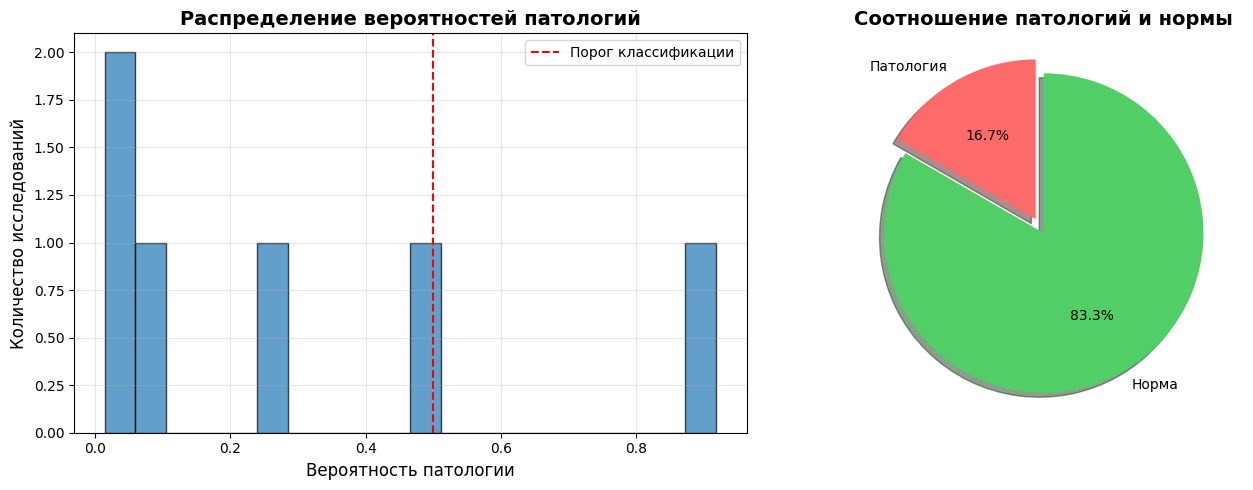

✅ Визуализация сохранена: quick_start_visualization.png


In [9]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
if len(existing_zips) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Распределение вероятностей
    axes[0].hist(df['probability_of_pathology'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(0.5, color='red', linestyle='--', label='Порог классификации')
    axes[0].set_xlabel('Вероятность патологии', fontsize=12)
    axes[0].set_ylabel('Количество исследований', fontsize=12)
    axes[0].set_title('Распределение вероятностей патологий', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График 2: Pie chart результатов
    labels = ['Патология', 'Норма']
    sizes = [pathology_count, normal_count]
    colors = ['#ff6b6b', '#51cf66']
    explode = (0.1, 0)
    
    axes[1].pie(sizes, explode=explode, labels=labels, colors=colors,
                autopct='%1.1f%%', shadow=True, startangle=90)
    axes[1].set_title('Соотношение патологий и нормы', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('quick_start_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Визуализация сохранена: quick_start_visualization.png")

In [10]:
# =============================================================================
# == ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ
# =============================================================================
if len(existing_zips) > 0 and pathology_count > 0:
    print("\n" + "="*60)
    print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ")
    print("="*60)
    
    # Фильтруем только патологии
    pathologies = df[df['pathology'] == 1].sort_values('probability_of_pathology', ascending=False)
    
    print(f"\n📌 Топ-5 исследований с наивысшей вероятностью патологии:")
    for idx, row in pathologies.head(5).iterrows():
        series_short = row['series_uid'][:40] + "..." if len(row['series_uid']) > 40 else row['series_uid']
        print(f"\n{idx+1}. Series: {series_short}")
        print(f"   Вероятность: {row['probability_of_pathology']:.4f} ({row['probability_of_pathology']*100:.2f}%)")
        print(f"   Статус: {row['processing_status']}")


🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПАТОЛОГИЙ

📌 Топ-5 исследований с наивысшей вероятностью патологии:

6. Series: 1.2.643.5.1.13.13.12.2.77.8252.050204150...
   Вероятность: 0.9175 (91.75%)
   Статус: Success


In [11]:
print("\n" + "="*60)
print("QUICK START ЗАВЕРШЁН!")
print("="*60)
print("\n Что было сделано:")
print("   1. Инициализирован pipeline с CT-CLIP и CatBoost")
print("   2. Обработаны ZIP архивы с медицинскими изображениями")
print("   3. Сгенерированы детальные результаты в Excel")
print("   4. Проведён анализ и визуализация данных")

print("\n📚 Следующие шаги:")
print("   - Изучите детальные результаты в quick_start_results.xlsx")
print("   - Проверьте лист 'Errors' для анализа ошибок")
print("   - Используйте лист 'Summary' для общей статистики")
print("   - Примените pipeline к вашим собственным данным")

print("\n📖 Дополнительная документация:")
print("   - notebooks/final.ipynb - полный эксперимент с обучением")
print("   - README.md - детальное описание системы")
print("   - src/pipeline/core_pipeline.py - API документация")

print("\n💡 Совет: Для обработки больших объёмов данных используйте:")
print("   - GPU для ускорения (device='cuda')")
print("   - Увеличьте max_workers для параллелизма")
print("   - Используйте batch обработку через glob")


QUICK START ЗАВЕРШЁН!

 Что было сделано:
   1. Инициализирован pipeline с CT-CLIP и CatBoost
   2. Обработаны ZIP архивы с медицинскими изображениями
   3. Сгенерированы детальные результаты в Excel
   4. Проведён анализ и визуализация данных

📚 Следующие шаги:
   - Изучите детальные результаты в quick_start_results.xlsx
   - Проверьте лист 'Errors' для анализа ошибок
   - Используйте лист 'Summary' для общей статистики
   - Примените pipeline к вашим собственным данным

📖 Дополнительная документация:
   - notebooks/final.ipynb - полный эксперимент с обучением
   - README.md - детальное описание системы
   - src/pipeline/core_pipeline.py - API документация

💡 Совет: Для обработки больших объёмов данных используйте:
   - GPU для ускорения (device='cuda')
   - Увеличьте max_workers для параллелизма
   - Используйте batch обработку через glob
